# transfer Learning with ensorFlor Part 3: Scaling up(Food Vision Mini)

We've seen the power of transfer learning feature ectraction and fine-tuning, now it's time to scale up to all of the classes in Food101 (101 total classses of food).

Our goal is to beat the original Food101 paper with 10% of the training (leveraging the power of deep learning).

[Food 101 paper](https://data.vision.ee.ethz.ch/cvl/datasets_extra/food-101/static/bossard_eccv14_food-101.pdf)

Our baseline to beat is 50.76% accuracy across 101 classes.

In [1]:
# ========================
# 🚀 CONFIGURAÇÃO RÁPIDA
# ========================
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '1'

import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print(f"TensorFlow {tf.__version__} - Geekom A9 Max")
devices = tf.config.list_physical_devices()
for d in devices:
    print(f"✅ {d.device_type.upper()}: {d.name}")

# Configurar gráficos
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = [12, 6]

print("✅ Notebook configurado!")


TensorFlow 2.15.0 - Geekom A9 Max
✅ CPU: /physical_device:CPU:0
✅ Notebook configurado!


In [2]:
# 📈 MONITOR DE PERFORMANCE
import time
from IPython.display import clear_output

class PerformanceMonitor:
    def __init__(self):
        self.start_time = None
        self.batch_times = []
    
    def start_epoch(self):
        self.start_time = time.time()
        self.batch_times = []
    
    def record_batch(self, batch_num, total_batches):
        elapsed = time.time() - self.start_time
        self.batch_times.append(elapsed)
        
        if batch_num % 10 == 0:
            avg_time = np.mean(self.batch_times[-10:]) if len(self.batch_times) >= 10 else elapsed
            eta = avg_time * (total_batches - batch_num)
            
            clear_output(wait=True)
            print(f"Batch {batch_num}/{total_batches}")
            print(f"Tempo/batch: {avg_time:.3f}s")
            print(f"ETA: {eta/60:.1f} minutos")
            print("-" * 40)

# Usar:
monitor = PerformanceMonitor()

In [3]:
import os
import tensorflow as tf

os.environ["TF_ENABLE_ONEDNN_OPTS"] = "1" 

tf.config.threading.set_intra_op_parallelism_threads(24)
tf.config.threading.set_inter_op_parallelism_threads(4)

tf.config.set_visible_devices([], 'GPU')

print("CPUs:", os.cpu_count())


CPUs: 24


### Creating helper functions

In previous notebooks, we've created a series of helper functions to different tasks.

In [4]:
# Import series of helper functions for our notebook
from helper_functions import create_tensorboard_callback, plot_loss_curves, unzip_data, compare_historys, walk_through_dir

## 101 Food Classes: working with less data

Our goal is to beat the original Food101 dataset but has been preprocessed using the image_data_modification.ipynb

In [5]:
# import zipfile
# import urllib.request

# # Baixar o arquivo ZIP
# url = "https://storage.googleapis.com/ztm_tf_course/food_vision/101_food_classes_10_percent.zip"
# zip_path = "101_food_classes_10_percent.zip"
# urllib.request.urlretrieve(url, zip_path)

# # # Descompactar o arquivo ZIP
# with zipfile.ZipFile(zip_path, "r") as zip_ref:
#     zip_ref.extractall()

train_dir = "101_food_classes_10_percent/train/"
test_dir = "101_food_classes_10_percent/test/"

In [6]:
# How many images/classes are there?
# check out how many images and subdirectorys are in our dataset
from helper_functions import walk_through_dir
walk_through_dir("101_food_classes_10_percent")

There are 2 directories and 0 images in '101_food_classes_10_percent'.
There are 101 directories and 0 images in '101_food_classes_10_percent\test'.
There are 0 directories and 250 images in '101_food_classes_10_percent\test\apple_pie'.
There are 0 directories and 250 images in '101_food_classes_10_percent\test\baby_back_ribs'.
There are 0 directories and 250 images in '101_food_classes_10_percent\test\baklava'.
There are 0 directories and 250 images in '101_food_classes_10_percent\test\beef_carpaccio'.
There are 0 directories and 250 images in '101_food_classes_10_percent\test\beef_tartare'.
There are 0 directories and 250 images in '101_food_classes_10_percent\test\beet_salad'.
There are 0 directories and 250 images in '101_food_classes_10_percent\test\beignets'.
There are 0 directories and 250 images in '101_food_classes_10_percent\test\bibimbap'.
There are 0 directories and 250 images in '101_food_classes_10_percent\test\bread_pudding'.
There are 0 directories and 250 images in '10

In [7]:
# Setup data inputs

from random import shuffle

import tensorflow as tf
IMG_SIZE = (224, 224)
train_data_all_10_percent = tf.keras.preprocessing.image_dataset_from_directory(
                                                                                train_dir,
                                                                                label_mode="categorical",
                                                                                image_size=IMG_SIZE)

test_data = tf.keras.preprocessing.image_dataset_from_directory(test_dir,
                                                                label_mode="categorical",
                                                                image_size=IMG_SIZE,
                                                                shuffle=False) # don't shuffle test data for prediction analysis

Found 7575 files belonging to 101 classes.
Found 25250 files belonging to 101 classes.


## Train a big dog model with transfer learning on 10% of 101 food classes

Here are the steps we're going to take:
* Create a ModelCheckpoint callback
* Create a data augmentation layer to build data augmentation right into the model
* Build a headless (no top layers) Functional EfficientNetB0 backboned-model (we'll create our own output layer)
* Compile our model
* Feature extract for 5 full passes (5 epochs on the train dataset and validate on 15% of the test data, to save epoch time)

In [8]:
# Create a ModelCheckpoint callback
checkpoint_path = "101_food_classes_10_percent_data_model_checkpoint"
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(checkpoint_path,
                                                         save_weights_only=True,
                                                         monitor="val_accuracy",
                                                         save_best_only=True)


In [9]:
# Create data augmentation layer to build data augmentation right into the Model
from tensorflow.keras import layers
from tensorflow.keras.layers.experimental import preprocessing
from tensorflow.keras.models import Sequential

# Setup data augmentation
data_augmentation = Sequential([
    preprocessing.RandomFlip("horizontal"),
    preprocessing.RandomRotation(0.2),
    preprocessing.RandomHeight(0.2),
    preprocessing.RandomZoom(0.2),
    preprocessing.RandomZoom(0.2),
    # preprocessing.Rescaling(1/255.) # rescale inputs of images to between 0 & 1, required for models like ResNet50
], name="data_augmentation")



In [10]:
# Setup the base model and freeze its layers (this will extract features)
base_model = tf.keras.applications.EfficientNetB0(include_top=False)
base_model.trainable = False

# Setup model architecture with trainable top layers
inputs = layers.Input(shape=(224, 224, 3), name='input_layer')
x = data_augmentation(inputs) # augment images (only happens during training phase)
x = base_model(x, training=False) # extract features from base model
x = layers.GlobalAveragePooling2D(name='global_avg_pool_layer')(x) # extract features from base model
outputs = layers.Dense(len(train_data_all_10_percent.class_names), activation='softmax', name='output_layer')(x) # output layer
model = tf.keras.Model(inputs, outputs)

In [11]:
# get a summary of model we've created
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (InputLayer)    [(None, 224, 224, 3)]     0         
                                                                 
 data_augmentation (Sequent  (None, None, 224, 3)      0         
 ial)                                                            
                                                                 
 efficientnetb0 (Functional  (None, None, None, 1280   4049571   
 )                           )                                   
                                                                 
 global_avg_pool_layer (Glo  (None, 1280)              0         
 balAveragePooling2D)                                            
                                                                 
 output_layer (Dense)        (None, 101)               129381    
                                                             

In [12]:
# Compile
model.compile(loss="categorical_crossentropy", 
              optimizer="adam", 
              metrics=["accuracy"])

# Fit
history_all_classes_10_percent = model.fit(train_data_all_10_percent, 
                                         epochs=5, # fit for 5 epochs to keep experiments quick
                                         validation_data=test_data, # use the test data for validation
                                         validation_steps=int(0.15 * len(test_data)), # 15% of the test data is used for validation
                                         callbacks = [checkpoint_callback]) # save the best model during training


Epoch 1/5


237/237 [==============================] - 81s 315ms/step - loss: 3.4762 - accuracy: 0.2477 - val_loss: 2.4731 - val_accuracy: 0.4711
Epoch 2/5
237/237 [==============================] - 74s 313ms/step - loss: 2.3296 - accuracy: 0.4692 - val_loss: 2.0163 - val_accuracy: 0.5199
Epoch 3/5
237/237 [==============================] - 72s 303ms/step - loss: 1.9617 - accuracy: 0.5376 - val_loss: 1.8543 - val_accuracy: 0.5400
Epoch 4/5
237/237 [==============================] - 77s 325ms/step - loss: 1.7526 - accuracy: 0.5752 - val_loss: 1.7758 - val_accuracy: 0.5450
Epoch 5/5
237/237 [==============================] - 74s 312ms/step - loss: 1.6023 - accuracy: 0.6058 - val_loss: 1.7284 - val_accuracy: 0.5506


In [13]:
# Evaluate on the whole test dataset
feature_extraction_results = model.evaluate(test_data)
print(feature_extraction_results)

790/790 [==============================] - 149s 189ms/step - loss: 1.6115 - accuracy: 0.5757
[1.6115198135375977, 0.5757227540016174]


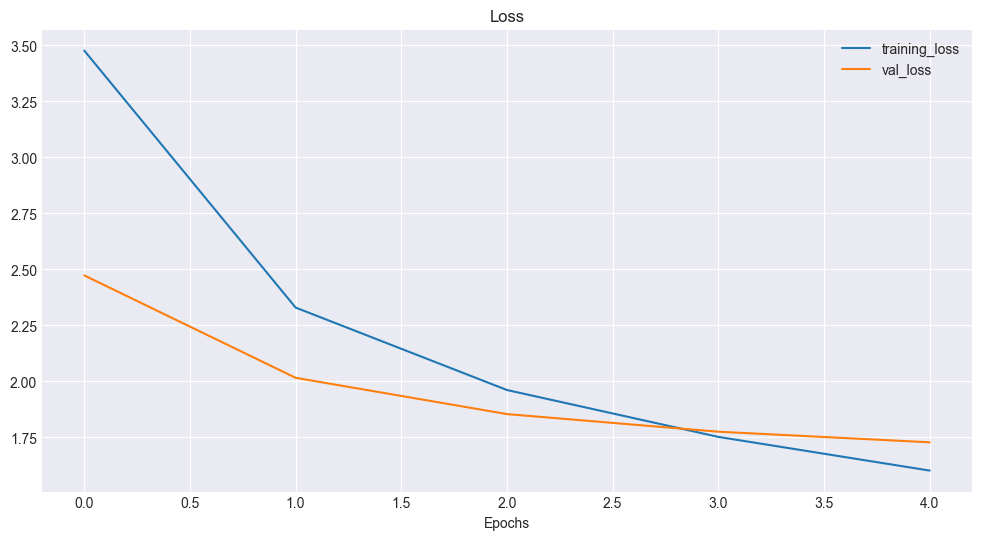

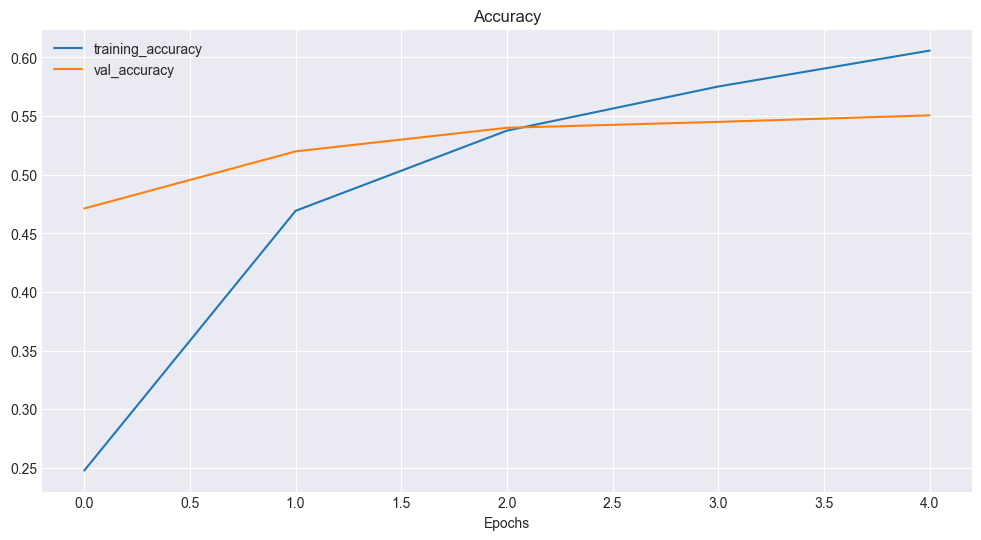

In [14]:
plot_loss_curves(history_all_classes_10_percent)

>> **Question:** What do these curves suggest? Hint: ideally, the two curves should be very similar to each other, if not it may suggest that our model is overfitting (performing too well on the training data and not generalizin to unseen data).

## Fine-tunning

In [15]:
# Unfreeze all of the layers in the base model
base_model.trainable = True

#Refreeze every layer except the last 5 layers
for layer in base_model.layers[:-5]:
    layer.trainable = False

In [16]:
# recompile model with lower learning rate (it's tipically best practice to lower the learing rate when fine-tuning)
model.compile(loss='categorical_crossentropy', 
              optimizer=tf.keras.optimizers.Adam(lr=0.0001), # learning rate lower by 10x 
              metrics=['accuracy'])

In [17]:
# What layers in the model are trainable?
for layer in model.layers:
    print(layer.name, layer.trainable)  

input_layer True
data_augmentation True
efficientnetb0 True
global_avg_pool_layer True
output_layer True


In [18]:
# Check wich layers are trainable in our base model
for layer_number, layer in enumerate(model.layers[2].layers):
    print(layer_number, layer.name, layer.trainable)

0 input_1 False
1 rescaling False
2 normalization False
3 rescaling_1 False
4 stem_conv_pad False
5 stem_conv False
6 stem_bn False
7 stem_activation False
8 block1a_dwconv False
9 block1a_bn False
10 block1a_activation False
11 block1a_se_squeeze False
12 block1a_se_reshape False
13 block1a_se_reduce False
14 block1a_se_expand False
15 block1a_se_excite False
16 block1a_project_conv False
17 block1a_project_bn False
18 block2a_expand_conv False
19 block2a_expand_bn False
20 block2a_expand_activation False
21 block2a_dwconv_pad False
22 block2a_dwconv False
23 block2a_bn False
24 block2a_activation False
25 block2a_se_squeeze False
26 block2a_se_reshape False
27 block2a_se_reduce False
28 block2a_se_expand False
29 block2a_se_excite False
30 block2a_project_conv False
31 block2a_project_bn False
32 block2b_expand_conv False
33 block2b_expand_bn False
34 block2b_expand_activation False
35 block2b_dwconv False
36 block2b_bn False
37 block2b_activation False
38 block2b_se_squeeze False
39

In [19]:
# Fine-tune for 5 more epochs
fine_tune_epochs = 10 # model has already done 5 epochs (feature extraction), this is the total number of epochs we're after (5 + 5 = 10)

# Fine-tuning our model
history_all_classes_10_percent_fine_tune = model.fit(train_data_all_10_percent,
                                                     epochs=fine_tune_epochs,
                                                     validation_data=test_data,
                                                     validation_steps=int(0.15 * len(test_data)),
                                                     initial_epoch=history_all_classes_10_percent.epoch[-1])

Epoch 5/10
237/237 [==============================] - 88s 336ms/step - loss: 1.6350 - accuracy: 0.5717 - val_loss: 1.8112 - val_accuracy: 0.5257
Epoch 6/10
237/237 [==============================] - 77s 324ms/step - loss: 1.2135 - accuracy: 0.6681 - val_loss: 1.9544 - val_accuracy: 0.5013
Epoch 7/10
237/237 [==============================] - 74s 313ms/step - loss: 0.9833 - accuracy: 0.7257 - val_loss: 1.8674 - val_accuracy: 0.5387
Epoch 8/10
237/237 [==============================] - 77s 326ms/step - loss: 0.8016 - accuracy: 0.7769 - val_loss: 1.7814 - val_accuracy: 0.5636
Epoch 9/10
237/237 [==============================] - 77s 323ms/step - loss: 0.6543 - accuracy: 0.8127 - val_loss: 2.0081 - val_accuracy: 0.5312
Epoch 10/10
237/237 [==============================] - 76s 320ms/step - loss: 0.5597 - accuracy: 0.8387 - val_loss: 2.0256 - val_accuracy: 0.5358


In [20]:
# Evaluate on the whole test dataset
all_classes_10_percent_fine_tune_results = model.evaluate(test_data)
all_classes_10_percent_fine_tune_results

790/790 [==============================] - 148s 188ms/step - loss: 1.9011 - accuracy: 0.5644


[1.9011008739471436, 0.5644356608390808]

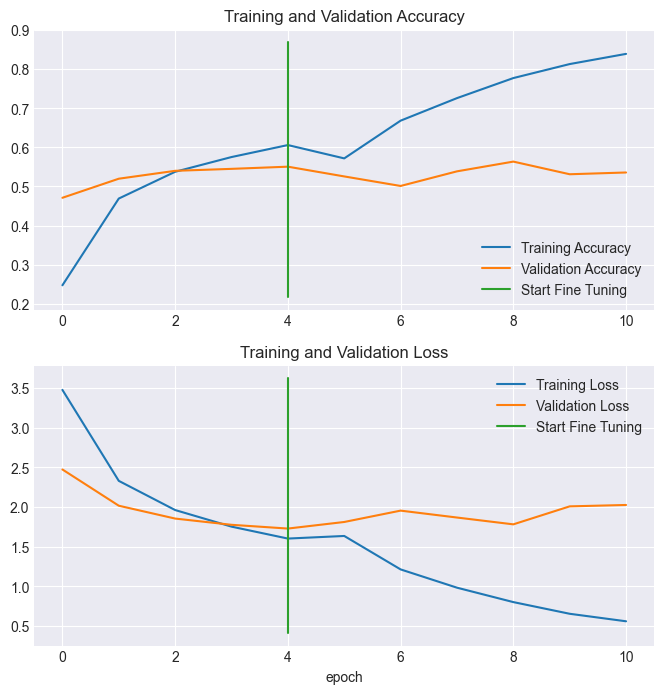

In [21]:
# Compare the histories of feature extraction model with fine-tuning model
compare_historys(original_history=history_all_classes_10_percent,
                 new_history=history_all_classes_10_percent_fine_tune,
                 initial_epochs=5)

## Saving and loading our model

To use our model in an external application, we'll need to save it and export it somewhere.

In [22]:
# Save our fine-tuning model
model.save("C:\\Project_1\\Tensorflow-1\\Files&notebooks\\06_Transfer_learning_scaling_up\\101_food_classes_10_percent_saved_big_dog_model")


INFO:tensorflow:Assets written to: C:\Project_1\Tensorflow-1\Files&notebooks\06_Transfer_learning_scaling_up\101_food_classes_10_percent_saved_big_dog_model\assets


INFO:tensorflow:Assets written to: C:\Project_1\Tensorflow-1\Files&notebooks\06_Transfer_learning_scaling_up\101_food_classes_10_percent_saved_big_dog_model\assets


In [23]:
# Load an evaluate saved model
loaded_model = tf.keras.models.load_model('C:\\Project_1\\Tensorflow-1\\Files&notebooks\\06_Transfer_learning_scaling_up\\101_food_classes_10_percent_saved_big_dog_model')

In [24]:
# Evaluate loaded model and compare performance to pre-saved model
loaded_model_results = loaded_model.evaluate(test_data)
loaded_model_results

790/790 [==============================] - 155s 193ms/step - loss: 1.9011 - accuracy: 0.5644


[1.9011008739471436, 0.5644356608390808]

In [25]:
# The resultes of our model above should be very similar to our model below
all_classes_10_percent_fine_tune_results

[1.9011008739471436, 0.5644356608390808]

## Evaluating the performance of the big dog model acorss all different classes

Let's make some predictions, visualize them and then later find out wich predictions were the "most" wrong.

In [26]:
# import zipfile
# import urllib.request
# import tensorflow as tf

# # Download pretrained model (one that was prepared earlier, so all predsictions are similar)
# # Baixar o arquivo ZIP
# url = "https://storage.googleapis.com/ztm_tf_course/food_vision/06_101_food_class_10_percent_saved_big_dog_model.zip"
# zip_path = "101_food_classes_10_percent.zip"
# urllib.request.urlretrieve(url, zip_path)

# # # Descompactar o arquivo ZIP
# with zipfile.ZipFile(zip_path, "r") as zip_ref:
#     zip_ref.extractall()


In [27]:
# Load in saved models
model = tf.keras.models.load_model("C:\\Project_1\\06_101_food_class_10_percent_saved_big_dog_model")

In [28]:
# evaluate loaded model (the one we just dowloaded on test data)
results_downloaded_model = model.evaluate(test_data)
print("Loss of downloaded model: ", results_downloaded_model[0])

790/790 [==============================] - 151s 189ms/step - loss: 1.8027 - accuracy: 0.6078
Loss of downloaded model:  1.8027209043502808


In [29]:
## Making predictions with our trained model
preds_probs = model.predict(test_data, verbose=1) # set verbosity to see how long is left

790/790 [==============================] - 147s 183ms/step


In [30]:
len(test_data)

790

In [31]:
790*32 # 

25280

In [32]:
# How many predictions are there?
len(preds_probs)

25250

In [33]:
# Whats the shape of our predictions?
preds_probs.shape # (images,shape)

(25250, 101)

In [34]:
# let's see what the first 10 predictions look like
preds_probs[:10]


array([[5.95418625e-02, 3.57423733e-06, 4.13773581e-02, ...,
        1.41387546e-09, 8.35309547e-05, 3.08973808e-03],
       [9.64016676e-01, 1.37531675e-09, 8.47801974e-04, ...,
        5.42870403e-05, 7.83623513e-12, 9.84660242e-10],
       [9.59258616e-01, 3.25336114e-05, 1.48669595e-03, ...,
        7.18917477e-07, 5.43963722e-07, 4.02757323e-05],
       ...,
       [4.73133028e-01, 1.29310834e-07, 1.48056541e-03, ...,
        5.97499602e-04, 6.69690198e-05, 2.34692707e-05],
       [4.45717759e-02, 4.72652545e-07, 1.22584715e-01, ...,
        6.34988646e-06, 7.53180802e-06, 3.67786223e-03],
       [7.24389851e-01, 1.92496685e-09, 5.23112540e-05, ...,
        1.22914289e-03, 1.57928104e-09, 9.63958664e-05]], dtype=float32)

In [35]:
# What does the first prediction probability look like?
preds_probs[0], len(preds_probs[0]), sum(preds_probs[0]) # ~ 1

(array([5.9541862e-02, 3.5742373e-06, 4.1377358e-02, 1.0660632e-09,
        8.1615035e-09, 8.6640126e-09, 8.0927788e-07, 8.5652709e-07,
        1.9859179e-05, 8.0978123e-07, 3.1727851e-09, 9.8675207e-07,
        2.8532289e-04, 7.8049467e-10, 7.4230268e-04, 3.8916329e-05,
        6.4740839e-06, 2.4977439e-06, 3.7891336e-05, 2.0678279e-07,
        1.5538519e-05, 8.1507454e-07, 2.6230955e-06, 2.0010869e-07,
        8.3827655e-07, 5.4216530e-06, 3.7391087e-06, 1.3150602e-08,
        2.7761601e-03, 2.8051878e-05, 6.8562650e-10, 2.5574944e-05,
        1.6689001e-04, 7.6407264e-10, 4.0453169e-04, 1.3150729e-08,
        1.7957352e-06, 1.4448224e-06, 2.3063021e-02, 8.2467142e-07,
        8.5365980e-07, 1.7138653e-06, 7.0525939e-06, 1.8402197e-08,
        2.8553472e-07, 7.9483725e-06, 2.0681803e-06, 1.8525216e-07,
        3.3619763e-08, 3.1522632e-04, 1.0411038e-05, 8.5449227e-07,
        8.4741831e-01, 1.0555541e-05, 4.4094858e-07, 3.7404487e-05,
        3.5306286e-05, 3.2489090e-05, 6.7314591e

Our model outputs a prediction probability array (with N number of variables, where N is the number of classes) for each sample passed to the predict method.

In [36]:
# We get one prediction probability per class ( in our case there's 101 prediction probabilities)
print(f"Number of prediction probabilities for sample 0: {len(preds_probs[0])}")
print(f"First prediction probability for sample 0: {preds_probs[0][0]}")
print(f"The class with the highest prediction probability by the model for sample 0: {np.argmax(preds_probs[0])}")

Number of prediction probabilities for sample 0: 101
First prediction probability for sample 0: 0.059541862457990646
The class with the highest prediction probability by the model for sample 0: 52


In [37]:
test_data.class_names

['apple_pie',
 'baby_back_ribs',
 'baklava',
 'beef_carpaccio',
 'beef_tartare',
 'beet_salad',
 'beignets',
 'bibimbap',
 'bread_pudding',
 'breakfast_burrito',
 'bruschetta',
 'caesar_salad',
 'cannoli',
 'caprese_salad',
 'carrot_cake',
 'ceviche',
 'cheese_plate',
 'cheesecake',
 'chicken_curry',
 'chicken_quesadilla',
 'chicken_wings',
 'chocolate_cake',
 'chocolate_mousse',
 'churros',
 'clam_chowder',
 'club_sandwich',
 'crab_cakes',
 'creme_brulee',
 'croque_madame',
 'cup_cakes',
 'deviled_eggs',
 'donuts',
 'dumplings',
 'edamame',
 'eggs_benedict',
 'escargots',
 'falafel',
 'filet_mignon',
 'fish_and_chips',
 'foie_gras',
 'french_fries',
 'french_onion_soup',
 'french_toast',
 'fried_calamari',
 'fried_rice',
 'frozen_yogurt',
 'garlic_bread',
 'gnocchi',
 'greek_salad',
 'grilled_cheese_sandwich',
 'grilled_salmon',
 'guacamole',
 'gyoza',
 'hamburger',
 'hot_and_sour_soup',
 'hot_dog',
 'huevos_rancheros',
 'hummus',
 'ice_cream',
 'lasagna',
 'lobster_bisque',
 'lobster

In [38]:
test_data.class_names[52]

'gyoza'

In [39]:
# Get the pred class of each label
pred_classes = np.argmax(preds_probs, axis=1)

# how many pred classes do we have?
len(pred_classes)

25250

Now we've got a predictions array of all of our model's predictions, to evaluate them, we need to compare them to the original test data

In [40]:
# To get our test labels we need to unravel our test_data BatchDataset
from numpy import test


y_labels = []
for images, labels in test_data. unbatch():
    y_labels.append(labels.numpy().argmax()) # currently test labels look like: [0, 0, 0, 1, ...., 0, 0] we wante the index value where the 1 occurs
y_labels[:10] # look at the first 10 labels

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

In [41]:
# How many y_labels do we have?
len(y_labels)

25250

In [42]:
test_data

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 101), dtype=tf.float32, name=None))>

## Evaluating our model's predictions
One way to check that our model's predictions array is in the same order as our test labels array is to find the accuracy score.

In [43]:
results_downloaded_model

[1.8027209043502808, 0.6077623963356018]

In [44]:
 # let's try scikit-learn's accuracy score function and see what it comes up with
import sklearn
from sklearn.metrics import accuracy_score
sklearn_accuracy = accuracy_score(y_true=y_labels,
                                  y_pred=pred_classes)

sklearn_accuracy

0.6077623762376237

In [45]:
# Does this metric come close to our model's evaluate results
import numpy as np
np.isclose(results_downloaded_model[1], sklearn_accuracy)

True

## let's get visual: making a confusion matrix

In [46]:
from helper_functions import make_confusion_matrix

In [47]:
# get a list of class names
class_names = test_data.class_names
class_names[:10]

['apple_pie',
 'baby_back_ribs',
 'baklava',
 'beef_carpaccio',
 'beef_tartare',
 'beet_salad',
 'beignets',
 'bibimbap',
 'bread_pudding',
 'breakfast_burrito']

In [48]:
make_confusion_matrix(  y_true=y_labels,
                        y_pred=pred_classes,
                        classes=class_names,
                        figsize=(100, 100),
                        text_size=20)

## let's keep the evaluation train going, time for a classification report

Sciki-learn has a helpfull function for acquiring many different classification metrics per class (e.g. precision, recall and F1) called [classification_report](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html), let's try it out:

In [49]:
from sklearn.metrics import classification_report
print(classification_report(y_true=y_labels, y_pred=pred_classes))

              precision    recall  f1-score   support

           0       0.29      0.20      0.24       250
           1       0.51      0.69      0.59       250
           2       0.56      0.65      0.60       250
           3       0.74      0.53      0.62       250
           4       0.73      0.43      0.54       250
           5       0.34      0.54      0.42       250
           6       0.67      0.79      0.72       250
           7       0.82      0.76      0.79       250
           8       0.40      0.37      0.39       250
           9       0.62      0.44      0.51       250
          10       0.62      0.42      0.50       250
          11       0.84      0.49      0.62       250
          12       0.52      0.74      0.61       250
          13       0.56      0.60      0.58       250
          14       0.56      0.59      0.57       250
          15       0.44      0.32      0.37       250
          16       0.45      0.75      0.57       250
          17       0.37    

The numbers above give a great class-by-class evaluation of our model's predictions but with so many classes, they're quite hard to understand.
How about we create a visualization to geta a better understanding of the performance of our model?

In [50]:
# Get a dictionary of the classification report
classification_report_dict = classification_report(y_labels, pred_classes, output_dict=True)
classification_report_dict

{'0': {'precision': 0.29310344827586204,
  'recall': 0.204,
  'f1-score': 0.24056603773584906,
  'support': 250.0},
 '1': {'precision': 0.5088235294117647,
  'recall': 0.692,
  'f1-score': 0.5864406779661017,
  'support': 250.0},
 '2': {'precision': 0.5625,
  'recall': 0.648,
  'f1-score': 0.6022304832713755,
  'support': 250.0},
 '3': {'precision': 0.7415730337078652,
  'recall': 0.528,
  'f1-score': 0.616822429906542,
  'support': 250.0},
 '4': {'precision': 0.7346938775510204,
  'recall': 0.432,
  'f1-score': 0.5440806045340051,
  'support': 250.0},
 '5': {'precision': 0.34177215189873417,
  'recall': 0.54,
  'f1-score': 0.4186046511627907,
  'support': 250.0},
 '6': {'precision': 0.6677966101694915,
  'recall': 0.788,
  'f1-score': 0.7229357798165138,
  'support': 250.0},
 '7': {'precision': 0.8197424892703863,
  'recall': 0.764,
  'f1-score': 0.7908902691511387,
  'support': 250.0},
 '8': {'precision': 0.4025974025974026,
  'recall': 0.372,
  'f1-score': 0.3866943866943867,
  'sup

In [51]:
class_names

['apple_pie',
 'baby_back_ribs',
 'baklava',
 'beef_carpaccio',
 'beef_tartare',
 'beet_salad',
 'beignets',
 'bibimbap',
 'bread_pudding',
 'breakfast_burrito',
 'bruschetta',
 'caesar_salad',
 'cannoli',
 'caprese_salad',
 'carrot_cake',
 'ceviche',
 'cheese_plate',
 'cheesecake',
 'chicken_curry',
 'chicken_quesadilla',
 'chicken_wings',
 'chocolate_cake',
 'chocolate_mousse',
 'churros',
 'clam_chowder',
 'club_sandwich',
 'crab_cakes',
 'creme_brulee',
 'croque_madame',
 'cup_cakes',
 'deviled_eggs',
 'donuts',
 'dumplings',
 'edamame',
 'eggs_benedict',
 'escargots',
 'falafel',
 'filet_mignon',
 'fish_and_chips',
 'foie_gras',
 'french_fries',
 'french_onion_soup',
 'french_toast',
 'fried_calamari',
 'fried_rice',
 'frozen_yogurt',
 'garlic_bread',
 'gnocchi',
 'greek_salad',
 'grilled_cheese_sandwich',
 'grilled_salmon',
 'guacamole',
 'gyoza',
 'hamburger',
 'hot_and_sour_soup',
 'hot_dog',
 'huevos_rancheros',
 'hummus',
 'ice_cream',
 'lasagna',
 'lobster_bisque',
 'lobster

Let's plot all of our classes F1-scores:

In [52]:
# create empty dictionary
class_f1_scores = {}
# Loop throught classification_reports dictionary items
for key, value in classification_report_dict.items():
    if key == "accuracy": # if key is accuracy, break the loop
        break
    else:
        # Add class names and f1-score to dictionary
        class_f1_scores[class_names[int(key)]] = value["f1-score"] 
class_f1_scores

{'apple_pie': 0.24056603773584906,
 'baby_back_ribs': 0.5864406779661017,
 'baklava': 0.6022304832713755,
 'beef_carpaccio': 0.616822429906542,
 'beef_tartare': 0.5440806045340051,
 'beet_salad': 0.4186046511627907,
 'beignets': 0.7229357798165138,
 'bibimbap': 0.7908902691511387,
 'bread_pudding': 0.3866943866943867,
 'breakfast_burrito': 0.5117370892018779,
 'bruschetta': 0.5047619047619047,
 'caesar_salad': 0.6161616161616161,
 'cannoli': 0.6105610561056105,
 'caprese_salad': 0.5775193798449613,
 'carrot_cake': 0.574757281553398,
 'ceviche': 0.3674418604651163,
 'cheese_plate': 0.5654135338345865,
 'cheesecake': 0.42546063651591287,
 'chicken_curry': 0.5008403361344538,
 'chicken_quesadilla': 0.6411889596602972,
 'chicken_wings': 0.7123809523809523,
 'chocolate_cake': 0.4526166902404526,
 'chocolate_mousse': 0.3291592128801431,
 'churros': 0.7134935304990758,
 'clam_chowder': 0.7708779443254818,
 'club_sandwich': 0.734020618556701,
 'crab_cakes': 0.46255506607929514,
 'creme_brulee'

In [53]:
# turn f1-scores into dataframe for visualization
import pandas as pd
f1_scores = pd.DataFrame({"class_name": list(class_f1_scores.keys()),
                           "f1_score": list(class_f1_scores.values())}).sort_values("f1_score", ascending=False)

In [54]:
f1_scores[:10]

,class_name,f1_score
33,edamame,0.937143
63,macarons,0.895397
75,pho,0.866538
91,spaghetti_carbonara,0.847656
69,oysters,0.834008
68,onion_rings,0.832618
65,mussels,0.820000
88,seaweed_salad,0.813008
64,miso_soup,0.812977
45,frozen_yogurt,0.811429


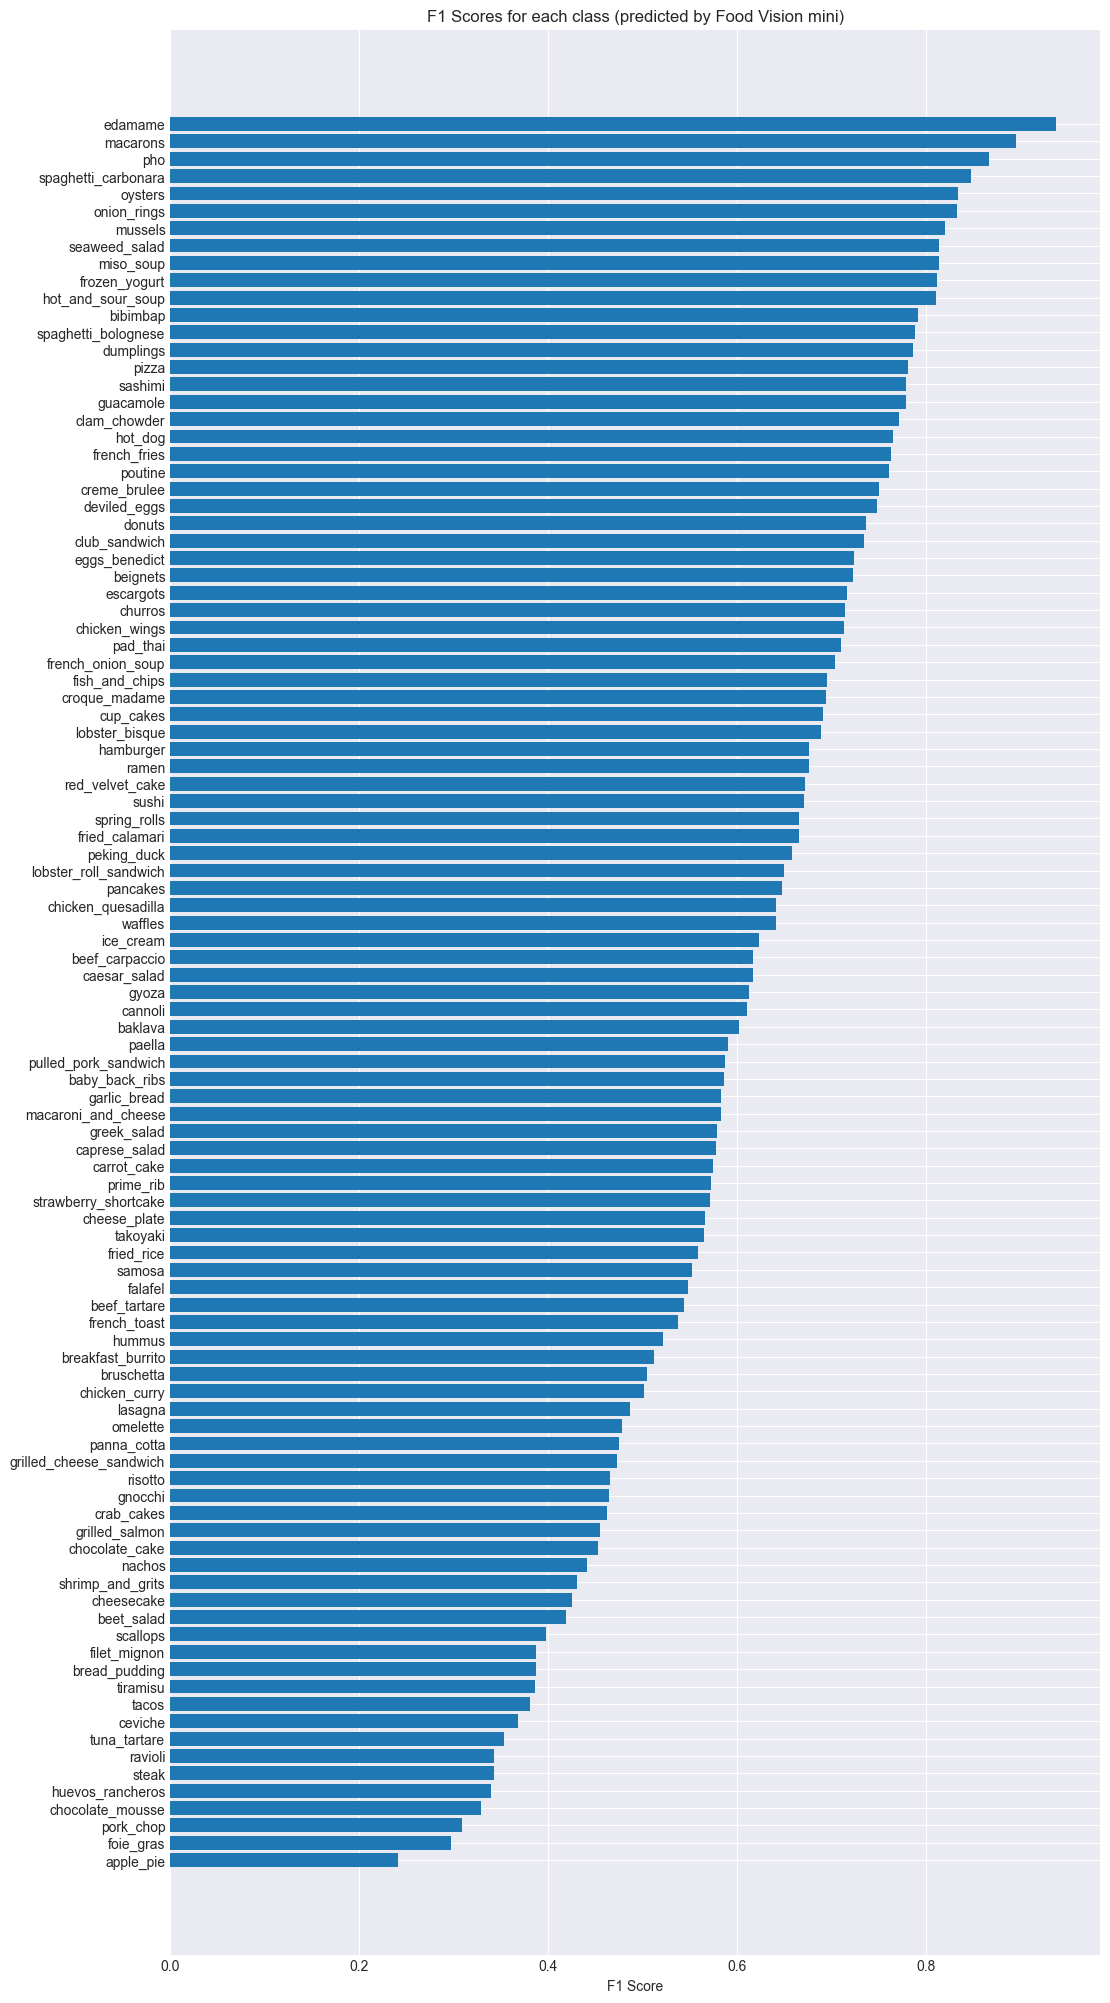

In [55]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 25))
scores = ax.barh(range(len(f1_scores)), f1_scores["f1_score"].values, align='center')
ax.set_yticks(range(len(f1_scores)))
ax.set_yticklabels(f1_scores["class_name"]); # ; remove the class names from the top
ax.set_xlabel("F1 Score")
ax.set_title("F1 Scores for each class (predicted by Food Vision mini)")
ax.invert_yaxis()

### Visualizing predictions on custom images

Now, this is the real test, how does our model go on food images not even in our test dataset (images of our own, we'' see this later on).

To visualize our model's predictions on our own images, we''l need a function to load and preprocess images, specifically it will need to:

* Read in a target image filepath using tf.io.read_file()
* Turn the image into a tensor using tf.image.decode_image()
* Resize the image to the size of our model's input layer using tf.image.resize()
* Scale the image to the range [0, 1] using tf.image.convert_image_dtype() - if necessary
* Return the preprocessed image

In [56]:
# Create a function to load and prepare images
def load_and_prep_image(filename, img_shape=224, scale=True):
    """
    Reads an image from filename, turns it into a tensor and reshapes into specified dhape (img_shape, img_shape, color_channels=3)

    Args:
        filename (string): path to the image
        img_shape (int): size of the smaller image dimensions (default 224)
        scale (bool): whether to scale pixel values to range [0, 1] (default True)
    Returns:
        img_tensor (tensor): tensor of shape (1, img_shape, img_shape, color_channels)
    """
    # Read in the image
    img = tf.io.read_file(filename)

    # Decode the image into a tensor
    img = tf.io.decode_image(img, channels=3)
    
    # Resize the image
    img = tf.image.resize(img, [img_shape, img_shape])

    # Scale the image
    if scale:
        # rescale the image to the range [0, 1]
        return img / 255.0
    else:
        return img # dont need to rescale images for EffficientNet models in tensorflow


Now we've got a function to load and prepare target images, let's now write some code to visualize images, their target label and our model's predictions.

Specifically, we'll write some code to:

1. Load a few random images from the test dataset
2. make predictions on the loaded images
3. Plot the original image(s) along with the model's predictions, prediction probabilities and truth label

1/1 [==============================] - 0s 51ms/step


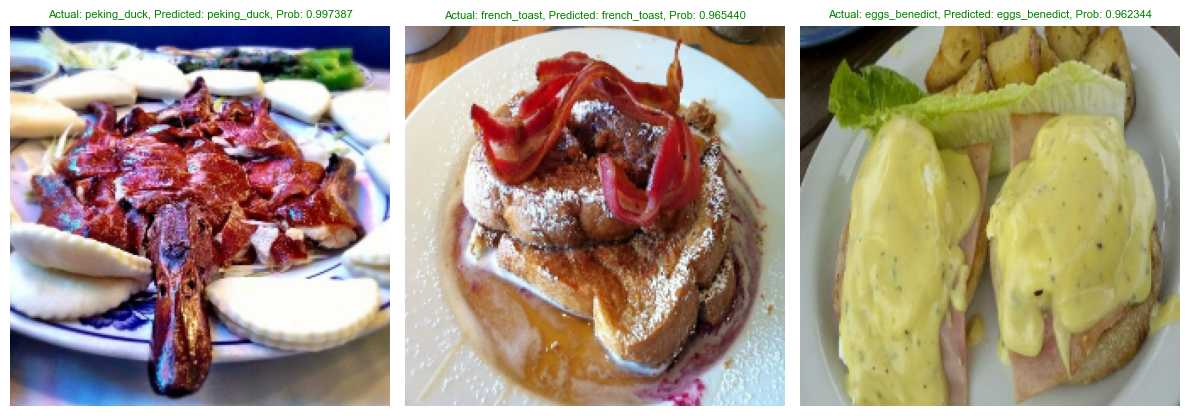

In [79]:
import os
import random
import matplotlib.pyplot as plt
import tensorflow as tf

plt.figure(figsize=(12, 6))

class_names = sorted(os.listdir(test_dir))
#print(class_names[:5])
for i in range(3):
    
    class_name = random.choice(class_names)

    # Proper path building
    class_path = os.path.join(test_dir, class_name)
    filename = random.choice(os.listdir(class_path))
    filepath = os.path.join(class_path, filename)

    img = load_and_prep_image(filepath, scale=False)
    #print(img)
    img_expanded = tf.expand_dims(img, axis=0)

    pred_prob = model.predict(img_expanded)
    pred_class = class_names[pred_prob.argmax()]

    #print("Predicted:", pred_class)

    # plot the images
    plt.subplot(1, 3, i+1)
    #print(img)
    plt.imshow(img/255.)
    if class_name == pred_class: # if predicted class matches truth class, make text green
        plt.title(f"Actual: {class_name}, Predicted: {pred_class}", color="green")
    else:
        plt.title(f"Actual: {class_name}, Predicted: {pred_class}, Prob: {pred_prob.max():2f}", color="red")

    plt.title(f"Actual: {class_name}, Predicted: {pred_class}, Prob: {pred_prob.max():2f}", fontsize=8)
    plt.axis("off")

plt.tight_layout()

## Finding the most wrong predictions

To find out where our model is most wrong, let's write some code to find out the following:
1. Get all of the image paths in the test dataset using [list_files()](https://www.tensorflow.org/api_docs/python/tf/data/Dataset) method
2. Create a pandas DataFrame of the image filepaths, ground truth labels, predicted classes (from our model), max prediction probabilities, prediction class names, ground truth class names
3. Use our DataFrame to find all the wrong predictions (where the ground truth label doesn't match the prediction).
4. Sort the DataFrame to find all the wrong predictions (where the ground truth label doesn't match the prediction).
5. Sort the DataFrame based on grong predictions (have the highest prediction probability predictions ate the top).
6. Visualize the images with the highes prediction probabilities but have the wrong prediction.

In [86]:
# 1. Get all of the image file paths in the test directory
filepaths = []
for filepath in test_data.list_files("101_food_classes_10_percent/test/*/*.jpg",
                                    shuffle=False):
    filepaths.append(filepath.numpy())
filepaths[:10]


[b'101_food_classes_10_percent\\test\\apple_pie\\1011328.jpg',
 b'101_food_classes_10_percent\\test\\apple_pie\\101251.jpg',
 b'101_food_classes_10_percent\\test\\apple_pie\\1034399.jpg',
 b'101_food_classes_10_percent\\test\\apple_pie\\103801.jpg',
 b'101_food_classes_10_percent\\test\\apple_pie\\1038694.jpg',
 b'101_food_classes_10_percent\\test\\apple_pie\\1047447.jpg',
 b'101_food_classes_10_percent\\test\\apple_pie\\1068632.jpg',
 b'101_food_classes_10_percent\\test\\apple_pie\\110043.jpg',
 b'101_food_classes_10_percent\\test\\apple_pie\\1106961.jpg',
 b'101_food_classes_10_percent\\test\\apple_pie\\1113017.jpg']

In [88]:
# 2. Create a DataFrame of different paramenetrs for each of our test images

import pandas as pd
pred_df = pd.DataFrame({"img_path": filepaths,
                        "y_true": y_labels,
                        "y_pred": pred_classes,
                        "pred_conf": preds_probs.max(axis=1),
                        "y_true_classname": [class_names[i] for i in y_labels],
                        "y_pred_classname": [class_names[i] for i in pred_classes]})
pred_df

,img_path,y_true,y_pred,pred_conf,y_true_classname,y_pred_classname
0,b'101_food_classes_10_percent\\test\\apple_pie...,0,52,0.847418,apple_pie,gyoza
1,b'101_food_classes_10_percent\\test\\apple_pie...,0,0,0.964017,apple_pie,apple_pie
2,b'101_food_classes_10_percent\\test\\apple_pie...,0,0,0.959259,apple_pie,apple_pie
3,b'101_food_classes_10_percent\\test\\apple_pie...,0,80,0.658607,apple_pie,pulled_pork_sandwich
4,b'101_food_classes_10_percent\\test\\apple_pie...,0,79,0.367902,apple_pie,prime_rib
...,...,...,...,...,...,...
25245,b'101_food_classes_10_percent\\test\\waffles\\...,100,100,0.972823,waffles,waffles
25246,b'101_food_classes_10_percent\\test\\waffles\\...,100,16,0.878028,waffles,cheese_plate
25247,b'101_food_classes_10_percent\\test\\waffles\\...,100,100,0.537899,waffles,waffles
25248,b'101_food_classes_10_percent\\test\\waffles\\...,100,94,0.501949,waffles,strawberry_shortcake


In [89]:
#3.  Find out in our dataFrame wich predictions are wrong
pred_df["pred_correct"] = pred_df["y_true"] == pred_df["y_pred"]
pred_df.head()

,img_path,y_true,y_pred,pred_conf,y_true_classname,y_pred_classname,pred_correct
0,b'101_food_classes_10_percent\\test\\apple_pie...,0,52,0.847418,apple_pie,gyoza,False
1,b'101_food_classes_10_percent\\test\\apple_pie...,0,0,0.964017,apple_pie,apple_pie,True
2,b'101_food_classes_10_percent\\test\\apple_pie...,0,0,0.959259,apple_pie,apple_pie,True
3,b'101_food_classes_10_percent\\test\\apple_pie...,0,80,0.658607,apple_pie,pulled_pork_sandwich,False
4,b'101_food_classes_10_percent\\test\\apple_pie...,0,79,0.367902,apple_pie,prime_rib,False


In [91]:
# 4. Sort our DataFrame to have most wrong predictions at the top
top_100_wrong = pred_df[pred_df["pred_correct"] == False].sort_values("pred_conf", ascending=False)[:100]
top_100_wrong.head(25)

,img_path,y_true,y_pred,pred_conf,y_true_classname,y_pred_classname,pred_correct
21810,b'101_food_classes_10_percent\\test\\scallops\...,87,29,0.999997,scallops,cup_cakes,False
231,b'101_food_classes_10_percent\\test\\apple_pie...,0,100,0.999995,apple_pie,waffles,False
15359,b'101_food_classes_10_percent\\test\\lobster_r...,61,53,0.999988,lobster_roll_sandwich,hamburger,False
23539,b'101_food_classes_10_percent\\test\\strawberr...,94,83,0.999987,strawberry_shortcake,red_velvet_cake,False
21400,b'101_food_classes_10_percent\\test\\samosa\\3...,85,92,0.999981,samosa,spring_rolls,False
24540,b'101_food_classes_10_percent\\test\\tiramisu\...,98,83,0.999947,tiramisu,red_velvet_cake,False
2511,b'101_food_classes_10_percent\\test\\bruschett...,10,61,0.999945,bruschetta,lobster_roll_sandwich,False
5574,b'101_food_classes_10_percent\\test\\chocolate...,22,21,0.999939,chocolate_mousse,chocolate_cake,False
17855,b'101_food_classes_10_percent\\test\\paella\\2...,71,65,0.999931,paella,mussels,False
23797,b'101_food_classes_10_percent\\test\\sushi\\16...,95,86,0.999904,sushi,sashimi,False


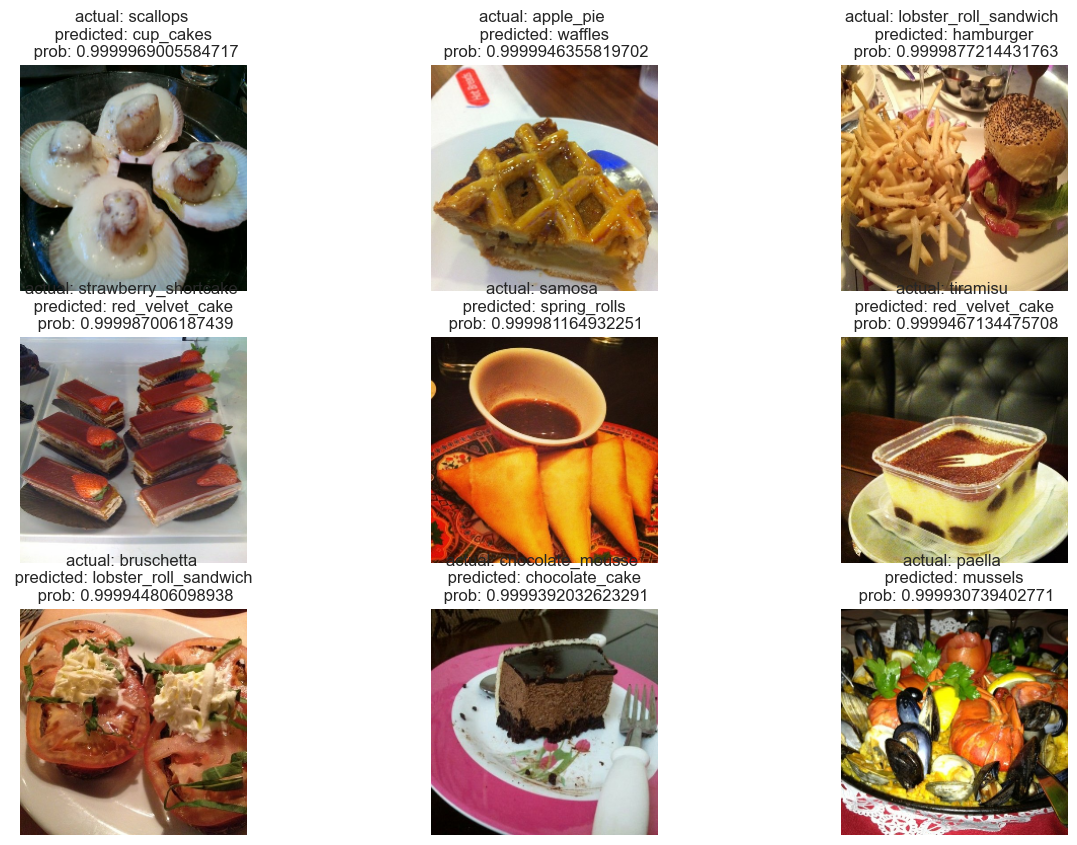

In [97]:
# 5. Visualize the test data samples wich have the wrong prediction but highest pred probability

images_to_view = 9
start_index = 0
plt.figure(figsize=(15, 10))
for i, row in enumerate(top_100_wrong[start_index:start_index+images_to_view].itertuples()):
    plt.subplot(3, 3, i+1)
    img = load_and_prep_image(row[1], scale=False)
    _, _, _, _, pred_prob, y_true_classname, y_pred_classname, _ = row # only interest in a few parameters
    plt.imshow(img/255.)
    plt.title(f"actual: {y_true_classname} \n predicted: {y_pred_classname} \n prob: {pred_prob:}")
    plt.axis(False)

## Test out the big dog model on our own custom images


In [ ]:
# get custom images

# import zipfile
# import urllib.request
# import tensorflow as tf

# # Download pretrained model (one that was prepared earlier, so all predsictions are similar)
# # Baixar o arquivo ZIP
# url = "https://storage.googleapis.com/ztm_tf_course/food_vision/custom_food_images.zip"
# zip_path = "custom_food_images.zip"
# urllib.request.urlretrieve(url, zip_path)

# # # Descompactar o arquivo ZIP
# with zipfile.ZipFile(zip_path, "r") as zip_ref:
#     zip_ref.extractall()

In [114]:
# get the custom food images filepaths
custom_food_images = ["custom_food_images/" + img_path for img_path in os.listdir("custom_food_images/")]
print(custom_food_images)

['custom_food_images/chicken_wings.jpeg', 'custom_food_images/hamburger.jpeg', 'custom_food_images/pizza-dad.jpeg', 'custom_food_images/ramen.jpeg', 'custom_food_images/steak.jpeg', 'custom_food_images/sushi.jpeg']


1/1 [==============================] - 0s 40ms/step


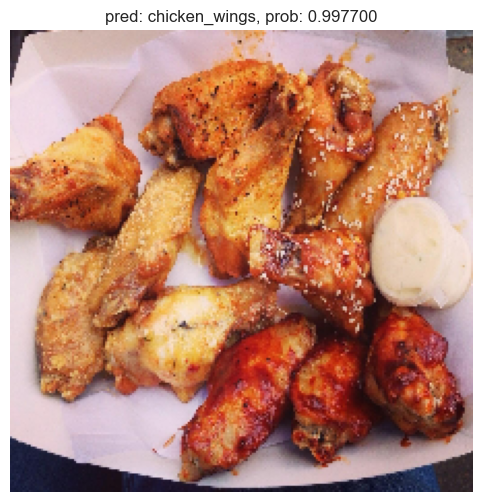

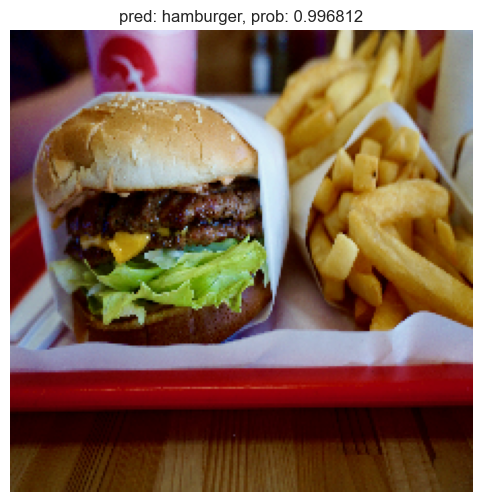

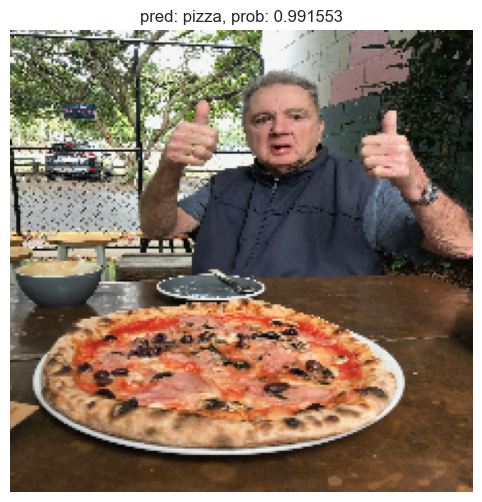

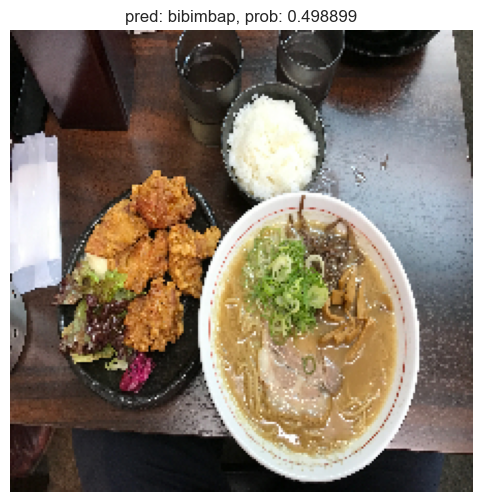

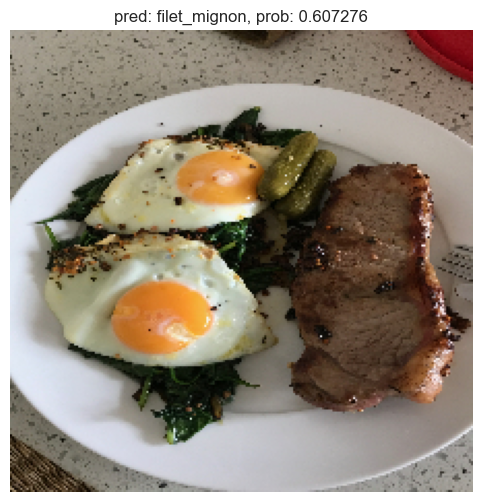

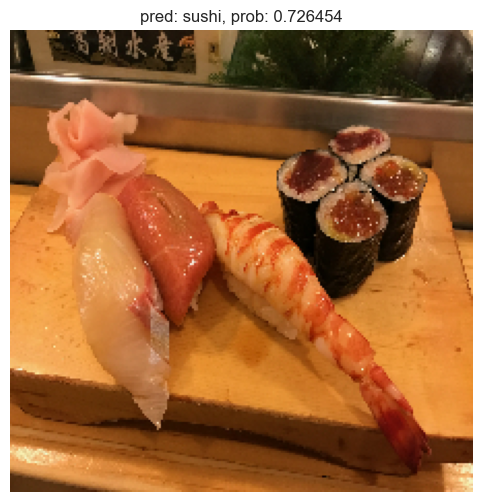

In [115]:
# make predictions on and plot custom food images
for img in custom_food_images:
    img = load_and_prep_image(img, scale=False) # don't need to scale for our EfficientNet model
    pred_prob = model.predict(tf.expand_dims(img, axis=0)) # make prediction on image with shape [1, 224, 224, 3] (same shape as model was trained on)
    pred_class = class_names[pred_prob.argmax()] # get the class name from the prediction
    # Plot the appropriate information
    plt.figure()
    plt.imshow(img/255.)
    plt.title(f"pred: {pred_class}, prob: {pred_prob.max():2f}")
    plt.axis(False)